# M3: obična RNN

Ova sveska trenira i ocenjuje M3 RNN nad sekvencama prethodno odigranih mečeva.

Svaka rekurentna arhitektura ima svoju svesku,
nezavisno od druge dve, da bi se moglo raditi paralelno bez sudara u istom
`.ipynb` fajlu. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu
petlju treniranja (`train.train_model`) - razlikuje se samo parametar `cell`.
Poređenje sve tri (i sa M0-M2) ide u svesku 05.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.


## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.config import MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE, RESULTS_FILE
from src import evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)


## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 - isti mečevi kao za M0/M1, kako bi poredjenje bilo pošteno. Test skup se ovde ne učitava iz istog razloga kao u svesci 03: dodiruje se tačno jednom, na kraju.

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape


((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` ovde meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe - ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
BATCH_SIZE = 64

dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)


(18092, 2624)

## Model i treniranje

`cell="rnn"` daje M3 RNN.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [4]:
model_rnn = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
    hidden_size=64,
    dropout=0.3,
)
model_rnn


MatchPredictor(
  (encoder): RNN(8, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=152, out_features=1, bias=True)
)

In [5]:
history = train.train_model(
    model_rnn, loader_train, loader_val,
    epochs=100, patience=5, learning_rate=1e-3,
)

best_epoch = int(np.argmin(history["valid_loss"]))
print(f"trenirano {len(history['train_loss'])} epoha (rano zaustavljanje)")
print(
    f"najbolja epoha: {best_epoch + 1}, "
    f"validacija gubitak {history['valid_loss'][best_epoch]:.4f}, "
    f"validacija tacnost {history['valid_accuracy'][best_epoch]:.4f}"
)


trenirano 21 epoha (rano zaustavljanje)
najbolja epoha: 16, validacija gubitak 0.6183, validacija tacnost 0.6555


## Krive učenja

Puna linija je trening, isprekidana validacija. Rastojanje između njih koje raste kroz epohe je znak overfitovanja — mreža pamti trening umesto da uči opšti obrazac. Tačka gde se validacioni gubitak prestaje popravljati (epoha 16) je i tačka u kojoj su sačuvane konačne težine.

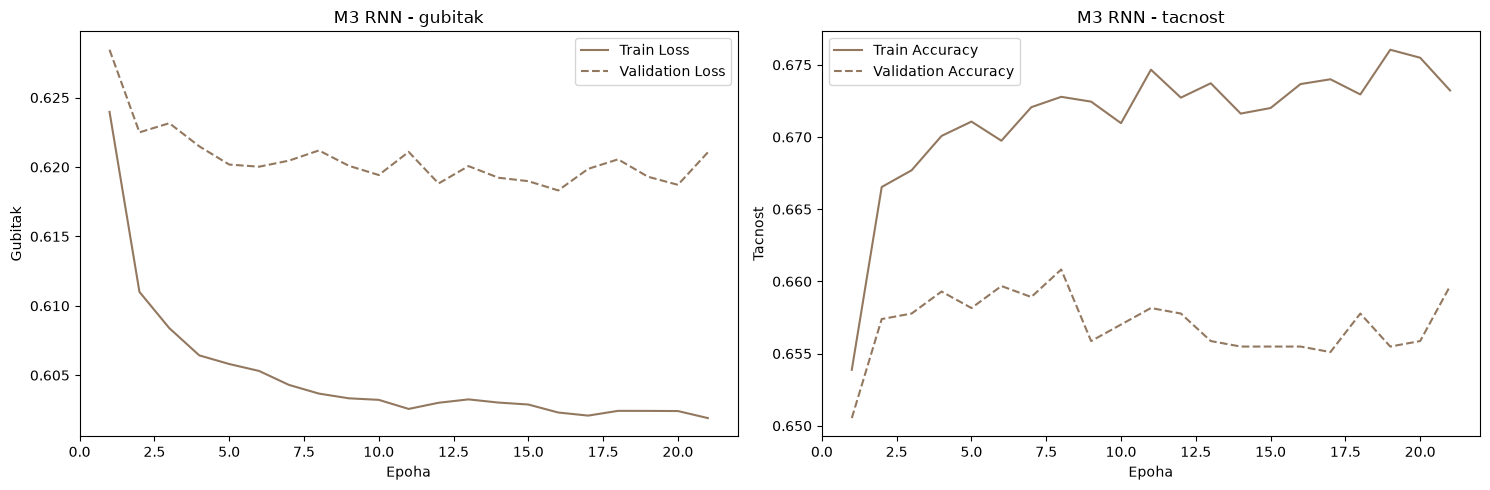

In [6]:
plotting.plot_learning_curves(history, "M3 RNN")


## Evaluacija

Matrica konfuzije i kalibracija na validaciji, metrike u `reports/rezultati.csv` — isti obrazac kao za M0/M1 u svesci 03. Test skup se ne dodiruje ovde.

In [7]:
for skup, loader in [("trening", loader_train), ("validacija", loader_val)]:
    y_proba, y_true = train.predict_proba(model_rnn, loader)
    metrike = evaluate.compute_metrics(y_true, y_proba)
    evaluate.append_results("M3 RNN", skup, metrike)

pd.read_csv(RESULTS_FILE)


,model,skup,tacnost,roc_auc,log_loss,brier
0,M3 RNN,trening,0.676763,0.717653,0.600141,0.206907
1,M3 RNN,validacija,0.655488,0.696478,0.618315,0.214417


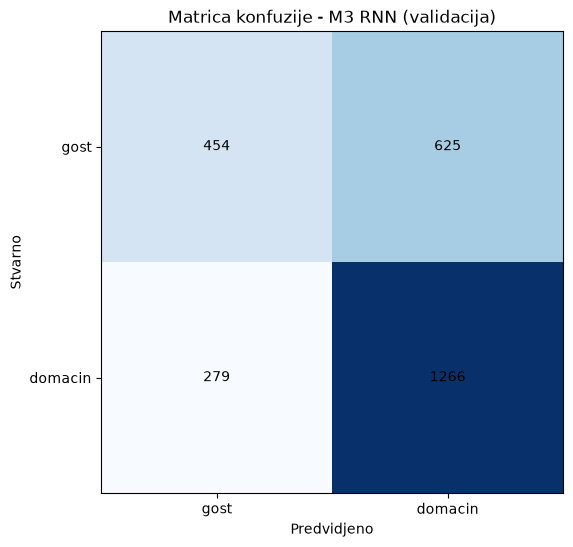

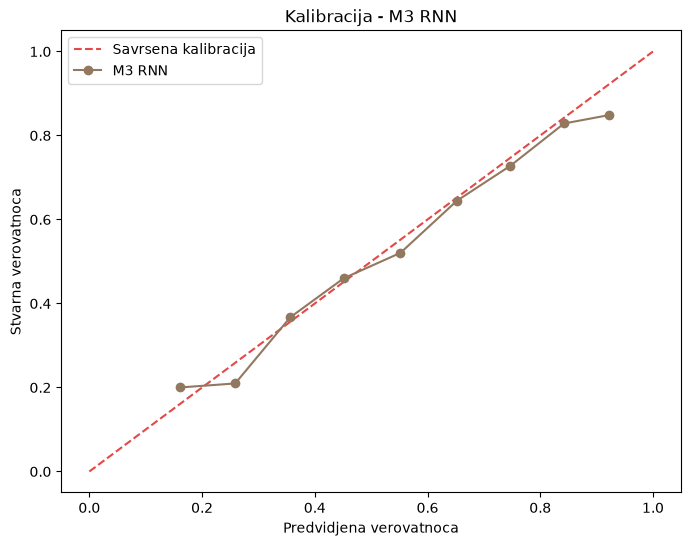

In [8]:
y_proba_val, y_true_val = train.predict_proba(model_rnn, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M3 RNN (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M3 RNN")


Model bolje prepoznaje pobede domaćina (82% recall) nego pobede gosta (42% recall) — posledica neravnoteže klasa (~59% pobeda domaćina u treningu), ne greška u arhitekturi. Kalibracija dobro prati dijagonalu u srednjem opsegu, uz blagu prekomernu samouverenost kod najviših predviđenih verovatnoća (~0.9 predviđeno naspram ~0.85 stvarno).

## Izbor hiperparametara

**TO DO**

## Čuvanje modela

Propozicije traže da se sačuvaju istrenirani modeli **i** propratni skaleri. Čuva se stanje sa najmanjim validacionim gubitkom, ne poslednje stanje.

In [9]:
train.save_model(model_rnn, "rnn.pt")


## Zaključak

M3 (obična RNN) dostiže 65.5% tačnosti na validaciji (ROC-AUC 0.696, log-loss 0.618, Brier 0.214) — praktično identično M1 logističkoj regresiji iz sveske 03 (65.6%, 0.695, 0.620, 0.215). Ovo je očekivan, ne razočaravajuć rezultat: plan projekta je unapred predvideo da snaga tima u toku sezone menja malo iz meča u meč, pa pokretni prosek (M1) već hvata skoro sav dostupan signal — sekvenci ostaje malo prostora da doda nešto preko toga.

Krive učenja pokazuju da se mreža skoro sva nauči u prve 3-4 epohe, posle čega se trening i validacija stabilizuju uz mali, konstantan razmak — nema znakova ozbiljnog overfitovanja, rano zaustavljanje (epoha 16 od 21) je uhvatilo šum, ne stvaran nastavak poboljšanja. Matrica konfuzije otkriva asimetriju, posledicu neravnoteže klasa: model prepoznaje 82% pobeda domaćina naspram samo 42% pobeda gosta. Kalibracija je solidna uz blagu prekomernu samouverenost kod najviših predviđenih verovatnoća.

Model je sačuvan u `models/rnn.pt`. Sledeći korak je ista arhitektura sa `cell="lstm"` i `cell="gru"` u svojim sveskama — pravo pitanje je da li kapije tih ćelija uspevaju da izvuku više iz duže istorije, što je i razlog da se `SEQUENCE_LENGTH` ablacija ostavi za kad sve tri budu istrenirane, kao zajednički eksperiment. Test skup nije dotican nigde u ovoj svesci, to se čuva za kasnije, kada se M0-M5 porede istovremeno.